Импорты:

In [1]:
import numpy as np
import ollama
import pandas as pd
import re
import time
from datetime import datetime
from ollama import Client
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from scipy.stats import spearmanr

1) Входящий csv файл (4_1_3.csv) лежит в папке data_input.
2) Запускаем парсинг этого файла (extract_csv.py), получаем data.csv в папке data_processed 

In [2]:
%run extract_csv.py data_input/4_1_3.csv data_processed/data.csv

Файл data_processed/data.csv создан.
Обработано строк: 200


In [3]:
df=pd.read_csv('data_processed/data.csv')
df.head(3)

,student_id,question,correctAnswer_1,userAnswer_1,right_1,wrong_1,errors_1,correctAnswer_2,userAnswer_2,right_2,wrong_2,errors_2,automaticScore,totalScore,teacherScore
0,89589,Из Егорьевска в Коломну можно проехать двумя с...,1) 19 + 20 + 18 = 57 км – длина первого пути2)...,19+20+18=57 57-48=9,0.0,0.0,0.0,9,9.0,1.0,0.0,0.0,1,1,-1
1,164562,Из Егорьевска в Коломну можно проехать двумя с...,1) 19 + 20 + 18 = 57 км – длина первого пути2)...,19+20+18=56,0.0,0.0,0.0,9,56.0,0.0,1.0,1.0,0,0,-1
2,66987,Из Егорьевска в Коломну можно проехать двумя с...,1) 19 + 20 + 18 = 57 км – длина первого пути2)...,Можно проехать в Коломну двумя способами. Расс...,0.0,0.0,0.0,9,9.0,1.0,0.0,0.0,1,1,-1


3) В ручную размечаем data.csv и получаем data_marked.csv (в папке data_processed)
Добавляются 3 колонки H_1 H_2  (разметка первого и второго поля) H_C (разметка итоговый балл)

4) Для ускорения общего инференса вначале проверяем ответы из поля 2  (сам правильный ответ)
Логика: Если ответ правильный то 1. Если не правильный или отсутствует то 0.
На вход датафрейм student_id correctAnswer_2 userAnswer_2 На выход uswer_id  Score_2  сохраняем в data_processed/scores_2.csv


In [ ]:
# В общем случае могут быть и текстовые ответы не только float
def normalize(val):
    if pd.isna(val):
        return ''
    s = str(val).strip()
    # Пробуем преобразовать в число
    try:
        num = float(s)
        if num.is_integer():
            return str(int(num))
        else:
            return str(num)   
    except ValueError:
        return s
df = pd.read_excel('data_processed/data_marked.xlsx') 
df_sub = df[['student_id', 'correctAnswer_2', 'userAnswer_2']].copy()

# df_sub['Score_2'] = np.where(
#     (df_sub['userAnswer_2'].notna()) & 
#     (df_sub['userAnswer_2'].astype(float) == df_sub['correctAnswer_2'].astype(float)),
#     1,
#     0
# )
df_sub['Score_2'] = np.where(
    df_sub['userAnswer_2'].notna() &
    (df_sub['userAnswer_2'].apply(normalize) == df_sub['correctAnswer_2'].apply(normalize)),
    1,
    0
)

result = df_sub[['student_id', 'Score_2']]
result.to_csv('data_processed/scores_2.csv', index=False)

# Посмотрим результат
print(result.head())

   student_id  Score_2
0       89589        1
1      164562        0
2       66987        1
3       35780        1
4      141559        1


5) Создаем папки ggufs и modelfiles (внутри файл modelfile.yandex-gpt)
6) Скачиваем gguf https://huggingface.co/yandex/YandexGPT-5-Lite-8B-instruct-GGUF/tree/main
7) пишем в файле modelfile.yandex-gpt  FROM /models/ggufs/YandexGPT-5-Lite-8B-instruct-Q4_K_M.gguf
8) docker build -t ollama-yandex .
9) docker run -d -p 11436:11434   -v $(pwd)/ggufs:/ggufs   -v $(pwd)/modelfiles:/modelfiles:ro   --name ollama-container ollama-yandex 
Без флага --gpus all - Контейнеры по умолчанию не видят железо, таким образом искомый CPU инференс
10) Протестируем

In [ ]:
client = Client(host='http://localhost:11436')

response = client.chat(
    model='yandex-gpt',
    messages=[{'role': 'user', 'content': 'Назови цифру от 1 до 9 Ответь одной цифрой без пояснений'}]
)

print(response['message']['content'])



8


11) Запускаем инференс по датафрейму и формируем data_processed/Scores_1.csv

In [ ]:
# Точное время начала
start_time = datetime.now()
print("Старт инференса:", start_time.strftime("%H:%M:%S"))
df = pd.read_excel('data_processed/data_marked.xlsx')

# Так как порт не стандартный 11434 а 11436
client = Client(host='http://localhost:11436')

SYSTEM_PROMPT = """Ты — эксперт по математике для начальной школы. Оцени, правильный ли ответ ученика на задачу. 
Учитывай, что ответ должен содержать верное решение и правильный числовой результат. 
Если ответ ученика содержит правильное решение и правильный ответ, выведи 1. 
Если логически решение правильное но есть одна арифметическая ошибка в решении, выведи 1.
Если решение логически ошибочно или арифметических ошибок больше одной или решения вообще нет  выведи 0 
В ответе выведи только одну цифру: 1 или 0, ничего другого."""

MODEL_NAME = "yandex-gpt:latest"

def evaluate_answer(question, correct_answer, user_answer):
    """Оценивает ответ ученика с помощью модели."""
    if pd.isna(user_answer) or str(user_answer).strip() == '':
        return 0  # нет ответа

    # Формируем промпт для модели
    correct_answer += " Числовой правильный ответ 9"
    user_prompt = f"""Вопрос: {question}
Правильный ответ: {correct_answer}
Ответ ученика: {user_answer}
Оценка (только 1 или 0):"""

    
    try:
        response = client.chat(
            model=MODEL_NAME,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': user_prompt}
            ]
        )
        result_text = response['message']['content'].strip()
        # Пытаемся извлечь 0 или 1 из ответа
        match = re.search(r'[01]', result_text)
        if match:
            return int(match.group())
        else:
            print(f"Неожиданный ответ модели: {result_text}")
            return 0
    except Exception as e:
        print(f"Ошибка при запросе к модели: {e}")
        return 0

scores = []
total = len(df)

for idx, row in df.iterrows():
    student_id = row['student_id']
    question = row['question']
    correct = row['correctAnswer_1']
    user = row['userAnswer_1']

    score = evaluate_answer(question, correct, user)
    scores.append(score)

    if (idx + 1) % 10 == 0 or idx + 1 == total:
        print(f"Обработано {idx+1} из {total}")

    time.sleep(0.1)

result_df = pd.DataFrame({
    'student_id': df['student_id'],
    'Score_1': scores
})

result_df.to_csv('data_processed/scores_1.csv', index=False)
stop_time = datetime.now()
result_df['Score_1'].to_csv('data_processed/scores_11.csv', index=False)
print("Стоп инференса:", stop_time.strftime("%H:%M:%S"))
duration = stop_time - start_time
print("Продолжительность:", duration)
print("Готово! Файл scores_1.csv создан.")

Старт инференса: 20:10:43
Обработано 10 из 200
Обработано 20 из 200
Обработано 30 из 200
Обработано 40 из 200
Обработано 50 из 200
Обработано 60 из 200
Обработано 70 из 200
Обработано 80 из 200
Обработано 90 из 200
Обработано 100 из 200
Обработано 110 из 200
Обработано 120 из 200
Обработано 130 из 200
Обработано 140 из 200
Обработано 150 из 200
Обработано 160 из 200
Обработано 170 из 200
Обработано 180 из 200
Обработано 190 из 200
Обработано 200 из 200
Стоп инференса: 20:15:12
Продолжительность: 0:04:29.023513
Готово! Файл scores_1.csv создан.


12) Итоговые графики результатов. (Сравнение с H_C человеческой оценкой) . 


In [ ]:
# 1. Загружаем исходный файл
df = pd.read_excel('data_processed/data_marked.xlsx')
df_scores1 = pd.read_csv('data_processed/scores_1.csv')  
df_scores2 = pd.read_csv('data_processed/scores_2.csv')
# Объединяем
df = df.merge(df_scores1, on='student_id', how='left')
df = df.merge(df_scores2, on='student_id', how='left')

# 4. Вычисляем Score_C по правилу:
#    если Score_1 == 0, то Score_C = 0, иначе Score_C = Score_1 + Score_2
df['Score_C'] = np.where(df['Score_1'] == 0, 0, df['Score_1'] + df['Score_2'])

result_columns = [
    'student_id',
    'automaticScore',
    'totalScore',
    'H_1',
    'H_2',
    'H_C',
    'Score_1',
    'Score_2',
    'Score_C'
]

df_result = df[result_columns].copy()
df_result.to_excel('data_processed/results.xlsx', index=False)
df_result.to_csv('data_processed/results.csv', index=False)

print("Итоговый файл results.xlsx создан.")
#print(df_result.head())

Итоговый файл results.xlsx создан.


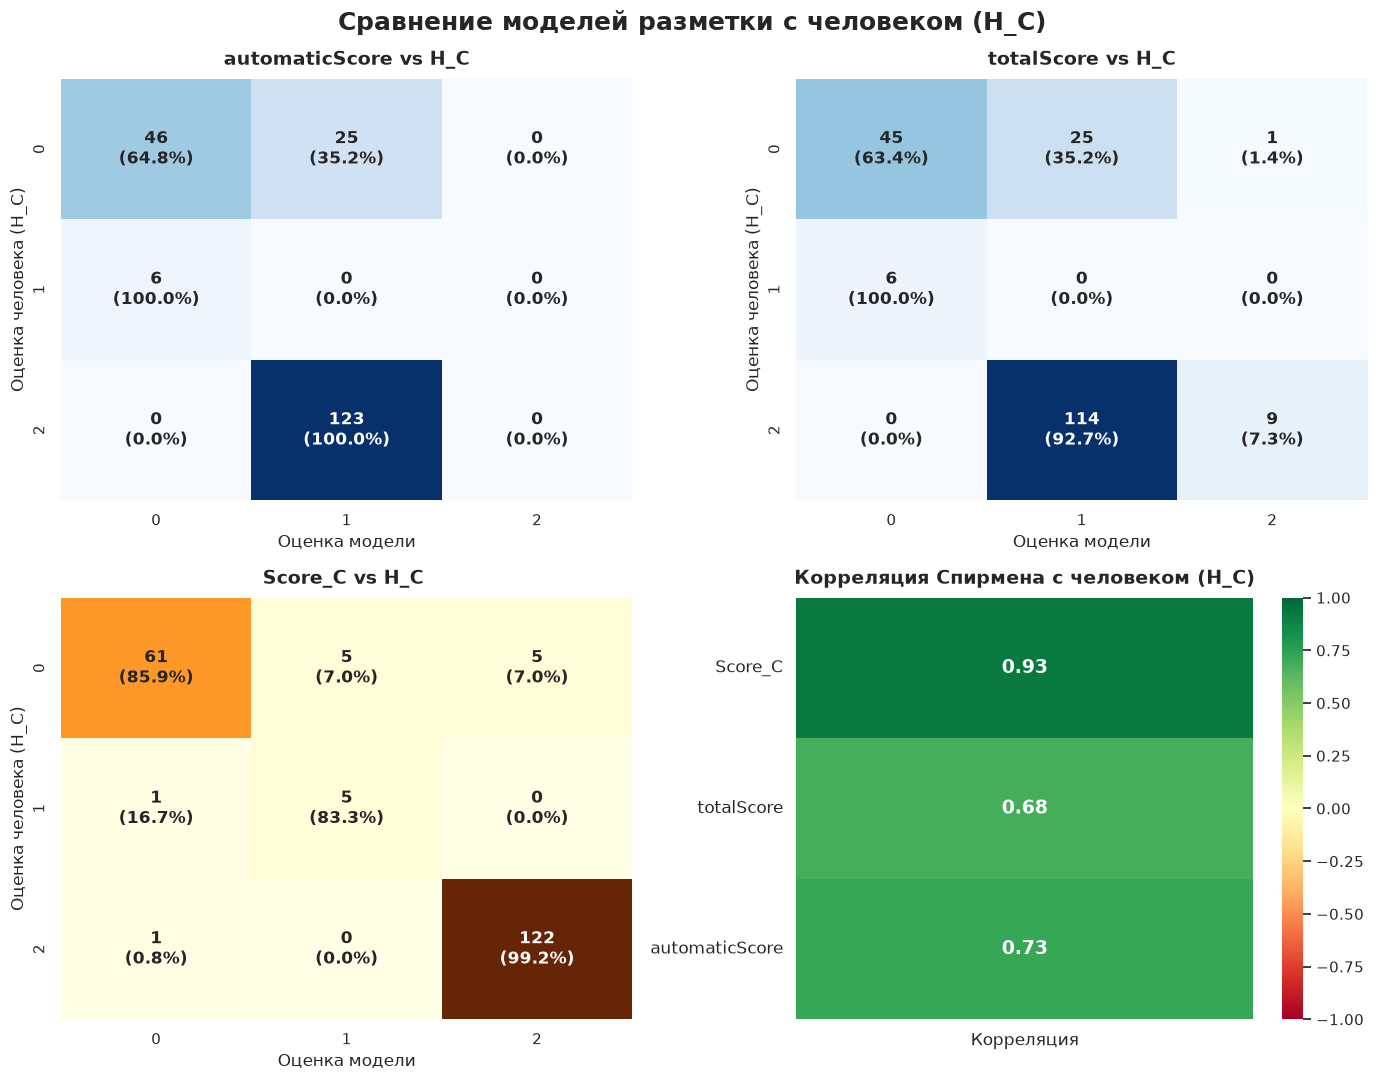


КРАТКИЙ АНАЛИЗ ТОЧНОСТИ (Метрики классификации):
Модель automaticScore совпадает с человеком в 23.0% случаев.
Модель totalScore совпадает с человеком в 27.0% случаев.
Модель Score_C совпадает с человеком в 94.0% случаев.


In [9]:
df = pd.read_excel('data_processed/results.xlsx')
num_cols = ['automaticScore', 'totalScore', 'H_C', 'Score_C']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
# стиль графиков
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Сравнение моделей разметки с человеком (H_C)', fontsize=18, fontweight='bold', y=0.98)

# Списки для построения графиков
models = ['automaticScore', 'totalScore', 'Score_C']
titles = ['automaticScore vs H_C', 'totalScore vs H_C', 'Score_C vs H_C ']

# (Confusion Matrices) 
for i, (model, title) in enumerate(zip(models, titles)):
    ax = axes[i // 2, i % 2]
    cm = confusion_matrix(df['H_C'], df[model], labels=[0, 1, 2])
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    labels = (np.array(["{0}\n({1:.1f}%)".format(count, pct) 
              for count, pct in zip(cm.flatten(), cm_percent.flatten())])).reshape(3, 3)
    cmap = "YlOrBr" if model == 'Score_C' else "Blues"
    sns.heatmap(cm, annot=labels, fmt="", cmap=cmap, cbar=False, ax=ax,
                xticklabels=[0, 1, 2], yticklabels=[0, 1, 2], annot_kws={"size": 12, "weight": "bold"})
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel('Оценка модели', fontsize=12)
    ax.set_ylabel('Оценка человека (H_C)', fontsize=12)

#Тепловая карта корреляции Спирмена ---
ax_corr = axes[1, 1]
num_cols = ['H_C', 'Score_C', 'totalScore', 'automaticScore']
corr_matrix, _ = spearmanr(df[num_cols])
corr_df = pd.DataFrame(corr_matrix, columns=num_cols, index=num_cols)
# Берем только колонку 'H_C' (связь с человеком) и убираем строку 'H_C' (связь человека с самим собой)
corr_with_human = corr_df[['H_C']].drop('H_C')

sns.heatmap(corr_with_human, annot=True, fmt=".2f", cmap="RdYlGn", 
            vmin=-1, vmax=1, cbar=True, ax=ax_corr, annot_kws={"size": 14, "weight": "bold"})

ax_corr.set_title('Корреляция Спирмена с человеком (H_C)', fontsize=14, fontweight='bold', pad=10)
ax_corr.set_xticklabels(['Корреляция'], fontsize=12)
ax_corr.set_yticklabels(corr_with_human.index, rotation=0, fontsize=12)

# подгоняем размеры
plt.tight_layout()
plt.show()

# Текстовый отчет в консоль ---
print("\n" + "="*50)
print("КРАТКИЙ АНАЛИЗ ТОЧНОСТИ (Метрики классификации):")
print("="*50)
for model in models:
    accuracy = (df['H_C'] == df[model]).mean() * 100
    print(f"Модель {model} совпадает с человеком в {accuracy:.1f}% случаев.")